(sec:xray)=
# X-ray spectroscopies

VeloxChem provides access to a range of X‑ray spectroscopies by combining density‑functional theory with response theory techniques that enable the description of core‑level excitations and their characteristic spectral signatures. These methods allow the simulation of X‑ray absorption, emission, and related core‑level properties, thereby enabling chemically intuitive interpretation of spectral features. For a comprehensive review of theoretical approaches to X‑ray spectroscopies, see {cite}`norman_cr_2018`.

The ESCA molecule, ethyl trifluoroacetate (CF₃–CO–O–CH₂–CH₃), became historically important in X‑ray and photoelectron spectroscopies because its C 1s photoelectron spectrum displays four well‑separated and chemically distinct carbon binding energies, spanning more than 8 eV—a uniquely clear demonstration of chemical shifts arising from different charge environments at individual atomic sites. This spectrum rapidly became the pedagogical showcase for ESCA (Electron Spectroscopy for Chemical Analysis) following Kai Siegbahn’s development of high‑resolution photoelectron spectroscopy in the 1960s, and it has since served as a benchmark for both experimental methodology and theoretical modeling of core‑level shifts. The molecule continues to be used in modern X‑ray and photoelectron studies as a canonical reference system to illustrate how core‑level binding energies encode local electronic structure and substituent effects, linking directly to the foundational ESCA work recognized in [Siegbahn’s 1981 Nobel Prize.](https://www.nobelprize.org/prizes/physics/1981/summary/)

In [1]:
import veloxchem as vlx 

molecule = vlx.Molecule.read_xyz_string("""13
b3lyp/def2-svp optimized geometry
C              1.326024532622         0.471089167011        -1.154937296389
C              0.484399509715         0.908494386259         0.037569541020
C              0.270494167717        -0.188493907246         1.053914467110
O              0.701245126416        -1.308212251798         0.971080711541
C             -0.582260522270         0.210893702941         2.291730106998
F             -0.731967860619        -0.799813015071         3.135965340271
F             -1.800383044157         0.625073687043         1.897202571864
F              0.003899498844         1.231896946553         2.943599980006
H              1.453639490166         1.302028888463        -1.864264306255
H              0.853135331881        -0.368249103011        -1.686230702784
H              2.322713498820         0.134038471332        -0.833394707486
H              0.936346512410         1.764030447212         0.571699332428
H             -0.514670521097         1.267150587304        -0.270103071648""")

molecule.show(atom_indices=True)

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

(sec:xps)=
## XPS

X-ray Photoelectron Spectroscopy (XPS) probes the binding energies of core electrons and yields element-specific, chemically sensitive spectra in which each peak reflects the local electronic environment of an individual atomic site. In VeloxChem, XPS binding energies are obtained through the **ΔSCF approach**: a ground-state SCF calculation is performed first, followed by a separate SCF calculation for each core-hole state (i.e., one core electron is removed from the targeted atom). The binding energy for each site is then computed as the difference in total energies between the core-ionized and ground states, along with a correction for relativistic and relaxation effects. The `XPSDriver` automates this workflow—it iterates over all atoms of the chosen element, generates the corresponding core-hole reference states, and assembles the final spectrum. CAM-B3LYP is recommended as the exchange–correlation functional since its range-separated character captures core-orbital relaxation effects in a balanced way.

**Python script**


In [6]:
import veloxchem as vlx
import copy
import numpy as np

molecule = vlx.Molecule.read_xyz_string("""13
ESCA b3lyp/def2-svp optimized geometry
C              1.326024532622         0.471089167011        -1.154937296389
C              0.484399509715         0.908494386259         0.037569541020
C              0.270494167717        -0.188493907246         1.053914467110
O              0.701245126416        -1.308212251798         0.971080711541
C             -0.582260522270         0.210893702941         2.291730106998
F             -0.731967860619        -0.799813015071         3.135965340271
F             -1.800383044157         0.625073687043         1.897202571864
F              0.003899498844         1.231896946553         2.943599980006
H              1.453639490166         1.302028888463        -1.864264306255
H              0.853135331881        -0.368249103011        -1.686230702784
H              2.322713498820         0.134038471332        -0.833394707486
H              0.936346512410         1.764030447212         0.571699332428
H             -0.514670521097         1.267150587304        -0.270103071648""")

basis = vlx.MolecularBasis.read(molecule, "def2-svp")

# Ground state SCF
scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "cam-b3lyp"
scf_results = scf_drv.compute(molecule, basis)

xps_drv = vlx.XPSDriver()

xps_results_c = xps_drv.compute(molecule, basis, scf_drv, element='C')


                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

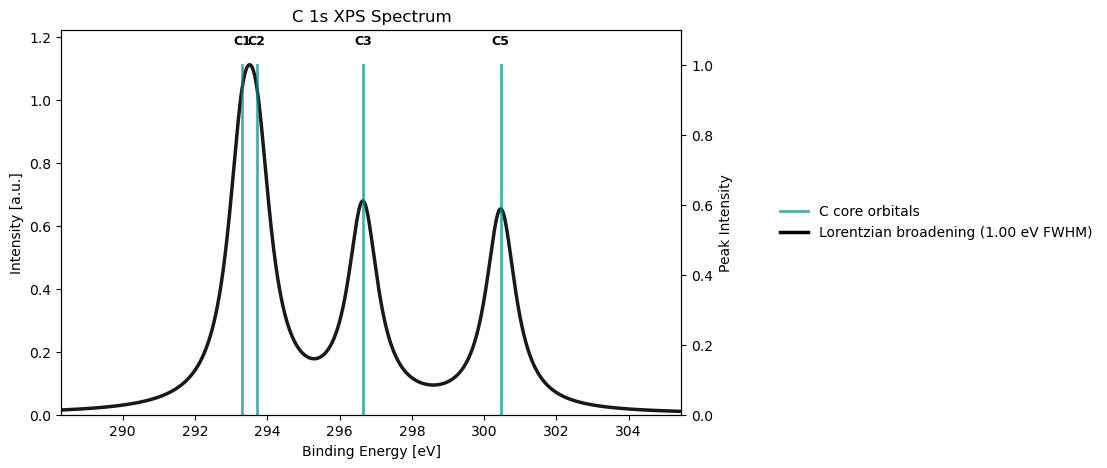

In [7]:
xps_drv.plot_spectrum(xps_results_c, element='C', broadening_type='lorentzian', broadening_value=1.0)

XPS spectra can also be calculated for several elements at a time:

```python
# Compute XPS for C, O, and F at once
xps_multi = xps_drv.compute(molecule, basis, scf_drv, elements=['C', 'O', 'F'])

# Plot 1: Carbon with atom labels (default)
xps_drv.plot_spectrum(xps_multi, element='C', color='vlx',
                      broadening_value=1.0, show_atom_labels=True)
# Plot 2: Carbon color-coded by atom
xps_drv.plot_spectrum(xps_multi, element='C', color='cpk',
                      broadening_value=1.0, color_by_atom=True)

# Plot 3: Oxygen with atom labels
xps_drv.plot_spectrum(xps_multi, element='O', color='cpk',
                      broadening_value=1.0)

# Plot 4: Fluorine with atom labels
xps_drv.plot_spectrum(xps_multi, element='F', color='cpk',
                      broadening_value=1.0)
```


(sec:nexafs)=
## NEXAFS

NEXAFS (or XANES) spectra can be calculated with the CPP solver by choosing the range of frequencies to the near ionization edge of the element you wish to probe. In terms of choice of functional, the version of the CAM-B3LYP functional with 100% exchange in the asymtotic limit has been shown in a comprehensive benchmark study to perform particularly well {cite}`fransson_xaboom_2021`.

**Python script**

In [3]:
import veloxchem as vlx
import numpy as np

molecule = vlx.Molecule.read_xyz_string("""13
ESCA b3lyp/def2-svp optimized geometry
C              1.326024532622         0.471089167011        -1.154937296389
C              0.484399509715         0.908494386259         0.037569541020
C              0.270494167717        -0.188493907246         1.053914467110
O              0.701245126416        -1.308212251798         0.971080711541
C             -0.582260522270         0.210893702941         2.291730106998
F             -0.731967860619        -0.799813015071         3.135965340271
F             -1.800383044157         0.625073687043         1.897202571864
F              0.003899498844         1.231896946553         2.943599980006
H              1.453639490166         1.302028888463        -1.864264306255
H              0.853135331881        -0.368249103011        -1.686230702784
H              2.322713498820         0.134038471332        -0.833394707486
H              0.936346512410         1.764030447212         0.571699332428
H             -0.514670521097         1.267150587304        -0.270103071648""")

basis = vlx.MolecularBasis.read(molecule, "def2-svp")

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = "cam-b3lyp"
scf_results = scf_drv.compute(molecule, basis)

cpp_drv = vlx.ComplexResponse()
cpp_drv.frequencies = np.arange(10.1, 10.4, 0.0025)
cpp_drv.property = "absorption"

cpp_results = cpp_drv.compute(molecule, basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

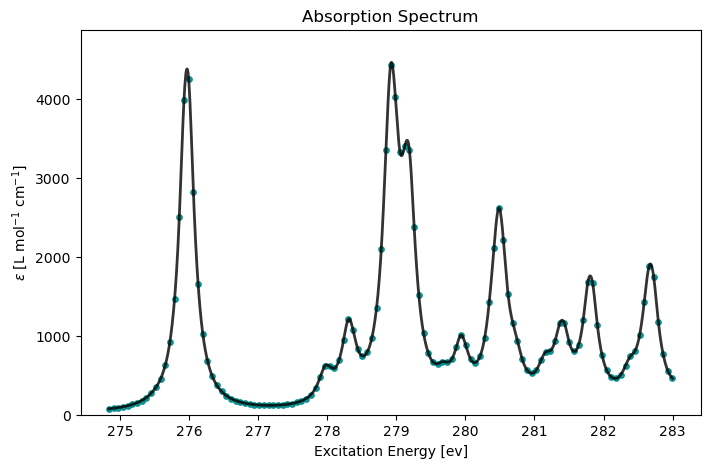

In [4]:
cpp_drv.plot(cpp_results, x_unit="eV")

**Text file**

:::{code}
@jobs
task: response
@end

@method settings
xcfun: cam-b3lyp
basis: def2-svp
@end

@response
property: absorption (cpp)
# frequency region (and resolution)
frequencies: 10.1-10.4 (0.0025)
@end

@molecule
charge: 0
multiplicity: 1
xyz:  
...
@end 
:::

Please refer to the [keyword list](#sec:cpp-keywords) for a complete set of options.

(sec:rixs)=
## RIXS

**Python script**

In [5]:
import veloxchem as vlx
import copy
import numpy as np

molecule = vlx.Molecule.read_xyz_string("""13
ESCA b3lyp/def2-svp optimized geometry
C              1.326024532622         0.471089167011        -1.154937296389
C              0.484399509715         0.908494386259         0.037569541020
C              0.270494167717        -0.188493907246         1.053914467110
O              0.701245126416        -1.308212251798         0.971080711541
C             -0.582260522270         0.210893702941         2.291730106998
F             -0.731967860619        -0.799813015071         3.135965340271
F             -1.800383044157         0.625073687043         1.897202571864
F              0.003899498844         1.231896946553         2.943599980006
H              1.453639490166         1.302028888463        -1.864264306255
H              0.853135331881        -0.368249103011        -1.686230702784
H              2.322713498820         0.134038471332        -0.833394707486
H              0.936346512410         1.764030447212         0.571699332428
H             -0.514670521097         1.267150587304        -0.270103071648""")

basis = vlx.MolecularBasis.read(molecule, "def2-svp")

xcfun = "cam-b3lyp"

scf_drv = vlx.ScfRestrictedDriver()
scf_drv.xcfun = xcfun
scf_results = scf_drv.compute(molecule, basis)

rixs_drv = vlx.RixsDriver()
rixs_drv.nstates = 20   # number of final valence-excited states
rixs_drv.num_core_orbitals = 8   # number of core orbitals
rixs_drv.num_core_states = 10  # number of intermediate core-excited states
rixs_drv.restricted_subspace = False 

rixs_drv.photon_energy = 276 / vlx.hartree_in_ev()  # value of the incoming photon energy in a.u.

rixs_results = rixs_drv.compute(molecule, basis, scf_results)

                                                                                                                          
                                            Self Consistent Field Driver Setup                                            
                                                                                                                          
                   Wave Function Model             : Spin-Restricted Kohn-Sham                                            
                   Initial Guess Model             : Superposition of Atomic Densities                                    
                   Convergence Accelerator         : Two Level Direct Inversion of Iterative Subspace                     
                   Max. Number of Iterations       : 50                                                                   
                   Max. Number of Error Vectors    : 10                                                                   
                

:::{image} ../images/esca-rixs.png
:align: center
:width: 600px
:::

**Text file**

:::{code}
@jobs
task: response
@end

@method settings
xcfun: cam-b3lyp
basis: def2-svp
@end

@response
property: rixs
photon_energy: 10.1428
nstates: 20
num_core_orbitals: 8
num_core_states: 10
restricted_subspace: False
@end

@molecule
charge: 0
multiplicity: 1
xyz:  
...
@end

:::